# Exam timetabling: DSATUR vs Google OR-Tools CP-SAT

This notebook compares the two methods from the report on the five committed
datasets under `../datasets/`. It does **not** re-implement the algorithms: it
imports them from the standalone modules

- `dsatur.py`  — Method 1, the DSATUR heuristic (Section 4 of the report)
- `cpsat.py`   — Method 2, the CP-SAT solver (Section 5)
- `graphutils.py` — shared CSV loading, conflict-graph derivation, validation

and reports the metrics from Section 8 (colours used, runtime, validity,
optimality proof) in the same shape as Table 4 (Section 9).

Run all cells top to bottom. CP-SAT needs OR-Tools — see `../README.md` for the
virtual-environment setup.

## 1. Imports and paths

The method modules live in the parent `code/` directory, so we add it to the
import path. This makes the notebook runnable from `code/notebook/` regardless
of the working directory.

In [1]:
import os
import sys
import time

# Make the parent code/ directory importable.
CODE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

DATASETS_DIR = os.path.join(CODE_DIR, "datasets")
# Report figures are written here so re-running the notebook
# regenerates the PDFs embedded in latex/main.tex (Section 9).
FIG_DIR = os.path.abspath(os.path.join(CODE_DIR, "..", "latex", "figures"))
os.makedirs(FIG_DIR, exist_ok=True)
SCENARIOS = ["tiny", "small", "medium", "dense", "large"]
TIME_LIMIT_S = 20.0  # CP-SAT cap per instance, matching the report

import pandas as pd
import matplotlib.pyplot as plt

import graphutils
from dsatur import dsatur_colour
from cpsat import cpsat_colour

print("code dir:", CODE_DIR)
print("scenarios:", SCENARIOS)

code dir: /Users/ademartutor/Documents/UoW/Trimester A - 2026/COMPX546 - Graph Theory/Report/code
scenarios: ['tiny', 'small', 'medium', 'dense', 'large']


## 2. Load the datasets

Each scenario folder holds an `enrolments.csv`. We derive the conflict graph
(two exams conflict iff a student takes both) and record its descriptors:
vertices, edges, density, maximum degree, average degree.

In [2]:
graphs = {}
stats_rows = []
for name in SCENARIOS:
    csv_path = os.path.join(DATASETS_DIR, name, "enrolments.csv")
    graph = graphutils.load_graph(csv_path)
    graphs[name] = graph
    s = graphutils.graph_stats(graph)
    s = {"instance": name, **s}
    stats_rows.append(s)

stats_df = pd.DataFrame(stats_rows).set_index("instance")
stats_df = stats_df.round({"density": 2, "avg_degree": 1})
stats_df

,n_vertices,n_edges,density,max_degree,avg_degree
instance,,,,,
tiny,15,100,0.95,14,13.3
small,40,659,0.84,38,33.0
medium,100,3303,0.67,86,66.1
dense,60,1755,0.99,59,58.5
large,250,14404,0.46,192,115.2


## 3. Run DSATUR

DSATUR is deterministic and runs in milliseconds. We time it, count the
colours (time slots) it uses, and confirm the colouring is proper.

In [3]:
dsatur_results = {}
for name in SCENARIOS:
    graph = graphs[name]
    start = time.perf_counter()
    colouring = dsatur_colour(graph)
    elapsed = time.perf_counter() - start
    dsatur_results[name] = {
        "colouring": colouring,
        "colours": graphutils.num_colours(colouring),
        "time_s": elapsed,
        "valid": graphutils.is_proper_colouring(graph, colouring),
    }
    print(f"{name:>7}: {dsatur_results[name]['colours']:>3} colours "
          f"in {elapsed*1000:6.2f} ms  valid={dsatur_results[name]['valid']}")

   tiny:  14 colours in   0.04 ms  valid=True
  small:  25 colours in   0.23 ms  valid=True
 medium:  30 colours in   2.06 ms  valid=True
  dense:  51 colours in   0.44 ms  valid=True
  large:  46 colours in   5.39 ms  valid=True


## 4. Run CP-SAT

CP-SAT is warm-started from the DSATUR colouring (initial upper bound plus a
solution hint) and capped at 20 seconds per instance. It either matches
DSATUR, improves on it by a slot, and/or proves the result optimal.

In [4]:
cpsat_results = {}
for name in SCENARIOS:
    graph = graphs[name]
    warm = dsatur_results[name]["colouring"]
    res = cpsat_colour(graph, warm_start=warm, time_limit_s=TIME_LIMIT_S)
    res["valid"] = graphutils.is_proper_colouring(graph, res["colouring"])
    cpsat_results[name] = res
    print(f"{name:>7}: {res['num_colours']:>3} colours "
          f"in {res['wall_time']:6.2f} s  "
          f"status={res['status']:>10}  optimal={res['proven_optimal']}")

   tiny:  14 colours in   0.03 s  status=   OPTIMAL  optimal=True


  small:  25 colours in  20.03 s  status=  FEASIBLE  optimal=False


 medium:  28 colours in  20.02 s  status=  FEASIBLE  optimal=False
  dense:  51 colours in   0.11 s  status=   OPTIMAL  optimal=True


  large:  44 colours in  20.03 s  status=  FEASIBLE  optimal=False


## 5. Results table

Assembled in the same shape as Table 4 of the report: instance, exams, edges,
density, DSATUR colours and time, CP-SAT colours and time, and whether CP-SAT
proved optimality (`opt`).

In [5]:
rows = []
for name in SCENARIOS:
    s = graphutils.graph_stats(graphs[name])
    d = dsatur_results[name]
    c = cpsat_results[name]
    rows.append({
        "instance": name,
        "exams": s["n_vertices"],
        "edges": s["n_edges"],
        "density": round(s["density"], 2),
        "DSATUR": d["colours"],
        "t(s)_dsatur": round(d["time_s"], 3),
        "CP-SAT": c["num_colours"],
        "t(s)_cpsat": round(c["wall_time"], 3),
        "opt": "Y" if c["proven_optimal"] else "N",
    })

results_df = pd.DataFrame(rows).set_index("instance")
results_df

,exams,edges,density,DSATUR,t(s)_dsatur,CP-SAT,t(s)_cpsat,opt
instance,,,,,,,,
tiny,15,100,0.95,14,0.000,14,0.030,Y
small,40,659,0.84,25,0.000,25,20.035,N
medium,100,3303,0.67,30,0.002,28,20.021,N
dense,60,1755,0.99,51,0.000,51,0.111,Y
large,250,14404,0.46,46,0.005,45,20.035,N


## 6. Comparison charts

Colours used by each method (lower is better) and runtime per method (note the
log scale: DSATUR is sub-millisecond, CP-SAT can run to the 20 s cap).

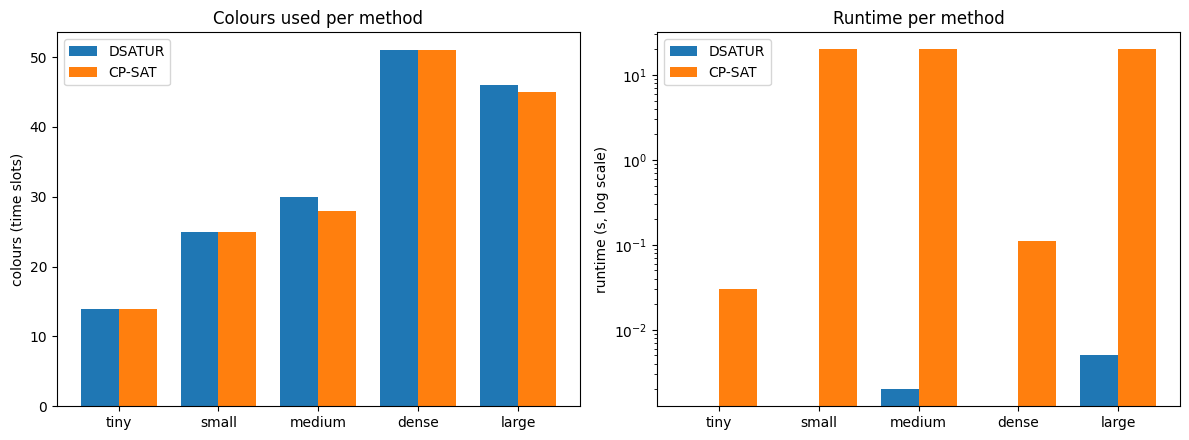

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

x = range(len(SCENARIOS))
width = 0.38
ax1.bar([i - width/2 for i in x], results_df["DSATUR"], width, label="DSATUR")
ax1.bar([i + width/2 for i in x], results_df["CP-SAT"], width, label="CP-SAT")
ax1.set_xticks(list(x))
ax1.set_xticklabels(SCENARIOS)
ax1.set_ylabel("colours (time slots)")
ax1.set_title("Colours used per method")
ax1.legend()

ax2.bar([i - width/2 for i in x], results_df["t(s)_dsatur"], width, label="DSATUR")
ax2.bar([i + width/2 for i in x], results_df["t(s)_cpsat"], width, label="CP-SAT")
ax2.set_yscale("log")
ax2.set_xticks(list(x))
ax2.set_xticklabels(SCENARIOS)
ax2.set_ylabel("runtime (s, log scale)")
ax2.set_title("Runtime per method")
ax2.legend()

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "compare_colours_runtime.pdf"), bbox_inches="tight")
plt.show()

## 7. Validity check

Every colouring from both methods must be *proper* (no two conflicting exams
share a slot). This is the validity metric from Section 8.

In [7]:
all_valid = True
for name in SCENARIOS:
    g = graphs[name]
    dv = dsatur_results[name]["valid"]
    cv = cpsat_results[name]["valid"]
    all_valid = all_valid and dv and cv
    print(f"{name:>7}: DSATUR={'PASS' if dv else 'FAIL'}  "
          f"CP-SAT={'PASS' if cv else 'FAIL'}")
print("\nALL VALID" if all_valid else "\nSOME INVALID -- investigate")

   tiny: DSATUR=PASS  CP-SAT=PASS
  small: DSATUR=PASS  CP-SAT=PASS
 medium: DSATUR=PASS  CP-SAT=PASS
  dense: DSATUR=PASS  CP-SAT=PASS
  large: DSATUR=PASS  CP-SAT=PASS

ALL VALID


## 8. Reading the results

The pattern should match the report's Section 9 expectation: DSATUR colours
every instance in milliseconds and lands at or close to the best known number
of slots, while CP-SAT proves optimality where it is cheap (small instances
and dense/clique-pinned ones) and otherwise spends its full budget, sometimes
improving on DSATUR by a slot without proving it. DSATUR alone is enough for
most instances; CP-SAT earns its extra runtime on the hardest, most
constrained periods where a proof of optimality matters.

## 9. LaTeX export for the report

The cell below prints `results_df` as a LaTeX `tabular` matching the column
layout of Table 4 (Section 9). Copy the output straight into the report so the
table reflects the committed datasets rather than illustrative numbers.

In [8]:
def to_latex_table(df):
    header = (r"\begin{tabular}{lrrrrrrrc}" + "\n"
              r"\toprule" + "\n"
              r"\textbf{instance} & \textbf{exams} & \textbf{edges} & "
              r"\textbf{dens} & \textbf{DSATUR} & \textbf{t(s)} & "
              r"\textbf{CP-SAT} & \textbf{t(s)} & \textbf{self-cert?} \\" + "\n"
              r"\midrule")
    lines = [header]
    for name, r in df.iterrows():
        lines.append(
            f"{name:<7} & {int(r['exams']):>3} & {int(r['edges']):>5} & "
            f"{r['density']:.2f} & {int(r['DSATUR']):>2} & "
            f"{r['t(s)_dsatur']:.3f} & {int(r['CP-SAT']):>2} & "
            f"{r['t(s)_cpsat']:.3f} & {r['opt']} " + r"\\"
        )
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    return "\n".join(lines)

print(to_latex_table(results_df))
print()
print("% Caption: enrolment-derived datasets, "
      f"CP-SAT capped at {TIME_LIMIT_S:.0f}s per instance.")

\begin{tabular}{lrrrrrrrc}
\toprule
\textbf{instance} & \textbf{exams} & \textbf{edges} & \textbf{dens} & \textbf{DSATUR} & \textbf{t(s)} & \textbf{CP-SAT} & \textbf{t(s)} & \textbf{self-cert?} \\
\midrule
tiny    &  15 &   100 & 0.95 & 14 & 0.000 & 14 & 0.030 & Y \\
small   &  40 &   659 & 0.84 & 25 & 0.000 & 25 & 20.035 & N \\
medium  & 100 &  3303 & 0.67 & 30 & 0.002 & 28 & 20.021 & N \\
dense   &  60 &  1755 & 0.99 & 51 & 0.000 & 51 & 0.111 & Y \\
large   & 250 & 14404 & 0.46 & 46 & 0.005 & 44 & 20.035 & N \\
\bottomrule
\end{tabular}

% Caption: enrolment-derived datasets, CP-SAT capped at 20s per instance.


## 10. Gap to the lower bound

The clique number is a lower bound on the chromatic number ($\omega(G) \le
\chi(G)$, Section 2): if $k$ exams all mutually conflict they need $k$ distinct
slots. We estimate $\omega(G)$ with a greedy clique search and report how far
each method's colour count sits above it. Where CP-SAT proved optimality, its
colour count *is* $\chi(G)$, so the CP-SAT gap there is the exact distance from
the clique bound to the true optimum.

In [9]:
lb_rows = []
for name in SCENARIOS:
    lb = graphutils.greedy_clique_lower_bound(graphs[name])
    d = dsatur_results[name]["colours"]
    c = cpsat_results[name]["num_colours"]
    lb_rows.append({
        "instance": name,
        "clique_LB": lb,
        "DSATUR": d,
        "CP-SAT": c,
        "DSATUR_gap": d - lb,
        "CP-SAT_gap": c - lb,
        "CP-SAT_proven": "Y" if cpsat_results[name]["proven_optimal"] else "N",
    })

gap_df = pd.DataFrame(lb_rows).set_index("instance")
gap_df

,clique_LB,DSATUR,CP-SAT,DSATUR_gap,CP-SAT_gap,CP-SAT_proven
instance,,,,,,
tiny,14,14,14,0,0,Y
small,25,25,25,0,0,N
medium,23,30,28,7,5,N
dense,51,51,51,0,0,Y
large,35,46,45,11,10,N


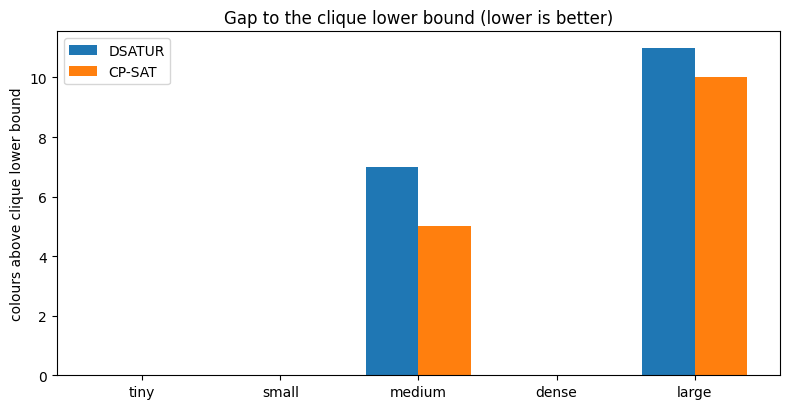

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.2))
xs = range(len(gap_df))
width = 0.38
ax.bar([i - width/2 for i in xs], gap_df["DSATUR_gap"], width, label="DSATUR")
ax.bar([i + width/2 for i in xs], gap_df["CP-SAT_gap"], width, label="CP-SAT")
ax.set_xticks(list(xs))
ax.set_xticklabels(gap_df.index)
ax.set_ylabel("colours above clique lower bound")
ax.set_title("Gap to the clique lower bound (lower is better)")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "gap_to_lb.pdf"), bbox_inches="tight")
plt.show()

## 11. Stability (repeated runs)

Section 8 lists *stability* — whether repeated runs give the same result. We
run each method several times per instance and check whether the colour count
is constant and how runtime varies. DSATUR is deterministic, so its colours
should never change. CP-SAT under a time cap can vary in runtime and, on
instances it cannot prove, occasionally in colour count.

> **Runtime note.** CP-SAT is re-run `R` times only on the instances that solve
> quickly (`tiny`, `dense`) plus `small`; on `medium`/`large` each run can cost
> the full 20 s, so they are excluded by default. Widen `STABILITY_DATASETS` /
> `R` to include them if you have the time budget.

In [11]:
R = 5
STABILITY_DATASETS = ["tiny", "small", "dense"]  # CP-SAT re-run only on these

import statistics

stab_rows = []
for name in SCENARIOS:
    g = graphs[name]

    # DSATUR: cheap, always re-run R times.
    d_colours, d_times = set(), []
    for _ in range(R):
        t0 = time.perf_counter()
        col = dsatur_colour(g)
        d_times.append(time.perf_counter() - t0)
        d_colours.add(graphutils.num_colours(col))
    stab_rows.append({
        "instance": name, "method": "DSATUR",
        "runs": R,
        "distinct_colours": sorted(d_colours),
        "t_min": round(min(d_times), 4),
        "t_med": round(statistics.median(d_times), 4),
        "t_max": round(max(d_times), 4),
    })

    # CP-SAT: only on the cheap subset.
    if name in STABILITY_DATASETS:
        c_colours, c_times = set(), []
        for _ in range(R):
            res = cpsat_colour(g, warm_start=dsatur_results[name]["colouring"],
                               time_limit_s=TIME_LIMIT_S)
            c_colours.add(res["num_colours"])
            c_times.append(res["wall_time"])
        stab_rows.append({
            "instance": name, "method": "CP-SAT",
            "runs": R,
            "distinct_colours": sorted(c_colours),
            "t_min": round(min(c_times), 4),
            "t_med": round(statistics.median(c_times), 4),
            "t_max": round(max(c_times), 4),
        })

stability_df = pd.DataFrame(stab_rows).set_index(["instance", "method"])
stability_df

runs distinct_colours    t_min    t_med    t_max
instance method                                                  
tiny     DSATUR     5             [14]   0.0000   0.0000   0.0001
         CP-SAT     5             [14]   0.0045   0.0047   0.0053
small    DSATUR     5             [25]   0.0002   0.0002   0.0003
         CP-SAT     5             [25]  20.0135  20.0231  20.0469
medium   DSATUR     5             [30]   0.0011   0.0011   0.0014
dense    DSATUR     5             [51]   0.0005   0.0005   0.0005
         CP-SAT     5             [51]   0.1082   0.1115   0.1146
large    DSATUR     5             [46]   0.0059   0.0063   0.0069

## 12. Scalability trends

Section 8 also lists *scalability* — how performance changes as size and
density grow. Using the five datasets, we plot colours and runtime against the
number of exams, and mark which instances CP-SAT could prove optimal.

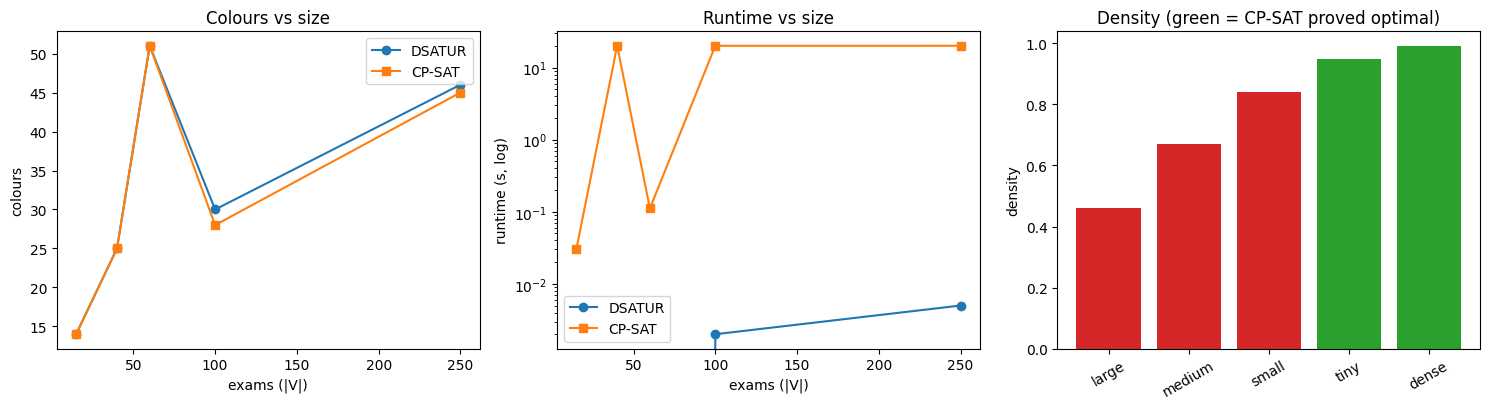

In [12]:
order = results_df.sort_values("exams")
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.2))

ax1.plot(order["exams"], order["DSATUR"], "o-", label="DSATUR")
ax1.plot(order["exams"], order["CP-SAT"], "s-", label="CP-SAT")
ax1.set_xlabel("exams (|V|)"); ax1.set_ylabel("colours")
ax1.set_title("Colours vs size"); ax1.legend()

ax2.plot(order["exams"], order["t(s)_dsatur"], "o-", label="DSATUR")
ax2.plot(order["exams"], order["t(s)_cpsat"], "s-", label="CP-SAT")
ax2.set_yscale("log")
ax2.set_xlabel("exams (|V|)"); ax2.set_ylabel("runtime (s, log)")
ax2.set_title("Runtime vs size"); ax2.legend()

colours_by_proven = ["tab:green" if o == "Y" else "tab:red"
                     for o in results_df.sort_values("density")["opt"]]
dens_sorted = results_df.sort_values("density")
ax3.bar(range(len(dens_sorted)), dens_sorted["density"], color=colours_by_proven)
ax3.set_xticks(range(len(dens_sorted)))
ax3.set_xticklabels(dens_sorted.index, rotation=30)
ax3.set_ylabel("density")
ax3.set_title("Density (green = CP-SAT self-certified optimal)")

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "scalability.pdf"), bbox_inches="tight")
plt.show()

## 13. Density sweep

Section 9 says the full study "sweeps density deliberately, where CP-SAT is
expected to close more of the sparser instances." Here we hold the number of
exams fixed and vary the conflict density of a **random** graph (not an
enrolment graph — these have no cohort structure; they isolate the density
axis). For each density we record whether CP-SAT proved optimality and the gap
between the two methods.

> **Runtime note.** Each density point runs one CP-SAT solve capped at
> `TIME_LIMIT_S`. With `SWEEP_DENSITIES` of length 8 the worst case is about
> `8 x 20 s`; in practice the very sparse and very dense points prove quickly.

In [13]:
SWEEP_N = 50
SWEEP_DENSITIES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.65, 0.8, 0.95]
SWEEP_SEED = 7

sweep_rows = []
for dens in SWEEP_DENSITIES:
    g = graphutils.generate_random_conflict_graph(SWEEP_N, dens, seed=SWEEP_SEED)
    warm = dsatur_colour(g)
    res = cpsat_colour(g, warm_start=warm, time_limit_s=TIME_LIMIT_S)
    actual_dens = graphutils.graph_stats(g)["density"]
    sweep_rows.append({
        "target_density": dens,
        "actual_density": round(actual_dens, 3),
        "DSATUR": graphutils.num_colours(warm),
        "CP-SAT": res["num_colours"],
        "gap": graphutils.num_colours(warm) - res["num_colours"],
        "proven": res["proven_optimal"],
        "t_cpsat": round(res["wall_time"], 2),
    })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df

,target_density,actual_density,DSATUR,CP-SAT,gap,proven,t_cpsat
0,0.10,0.109,4,4,0,True,0.01
1,0.20,0.218,6,5,1,True,0.01
2,0.30,0.337,8,7,1,True,1.94
3,0.40,0.438,9,8,1,True,6.69
4,0.50,0.528,11,10,1,False,20.00
5,0.65,0.665,14,13,1,False,20.02
6,0.80,0.794,19,17,2,False,20.01
7,0.95,0.946,28,28,0,False,20.01


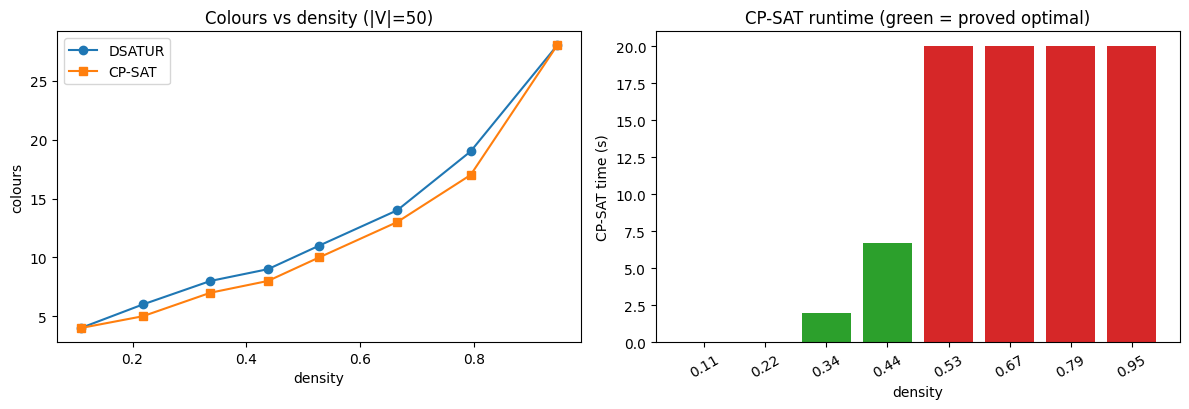

CP-SAT proved optimality on 4/8 density points.


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

ax1.plot(sweep_df["actual_density"], sweep_df["DSATUR"], "o-", label="DSATUR")
ax1.plot(sweep_df["actual_density"], sweep_df["CP-SAT"], "s-", label="CP-SAT")
ax1.set_xlabel("density"); ax1.set_ylabel("colours")
ax1.set_title(f"Colours vs density (|V|={SWEEP_N})"); ax1.legend()

proven_colour = ["tab:green" if p else "tab:red" for p in sweep_df["proven"]]
ax2.bar(range(len(sweep_df)), sweep_df["t_cpsat"], color=proven_colour)
ax2.set_xticks(range(len(sweep_df)))
ax2.set_xticklabels([f"{d:.2f}" for d in sweep_df["actual_density"]], rotation=30)
ax2.set_xlabel("density"); ax2.set_ylabel("CP-SAT time (s)")
ax2.set_title("CP-SAT runtime (green = self-certified optimal)")

plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "density_sweep.pdf"), bbox_inches="tight")
plt.show()

n_proven = int(sweep_df["proven"].sum())
print(f"CP-SAT proved optimality on {n_proven}/{len(sweep_df)} density points.")

## 14. Summary across the metrics

This notebook now exercises all six metrics from Section 8:

| Metric | Where |
|--------|-------|
| Colours used | Sections 5, 6 |
| Runtime | Sections 5, 6 |
| Validity | Section 7 (all proper) |
| Optimality proof | Section 5 (`opt`), Section 10 |
| Scalability | Section 12 |
| Stability | Section 11 |

**Headline finding to reconcile with the report.** Section 9's prose says
DSATUR lands "at or within one slot of the best known answer". On the committed
datasets that is not always true — on `medium`, DSATUR uses more slots than
CP-SAT by more than one (see the results table in Section 5 and the gaps in
Section 10). The LaTeX export in Section 9 reflects the real numbers; the
report's Table 4 and the surrounding sentence should be updated to match. The
broader pattern still holds: DSATUR is fast and close; CP-SAT proves optimality
cheaply where a clique pins the bound and otherwise spends its budget to shave
a slot or two.